# Reproducing Q-MAML on its own setting: Heisenberg XYZ VQE

**Why this notebook exists.** Before trusting our extension of Q-MAML to HEP classification
(`01_Higgs_QMAML_Paper_Faithful.ipynb`), we validate the reimplementation itself
(`final_model/meta/qmaml_paper_loops.py`'s Algorithm 1/2 logic, here reapplied via
`final_model/vqe_qmaml.py`) against the **exact setting the original paper used**: the
Heisenberg XYZ Hamiltonian VQE task space (Lee, Cho & Kim 2025, arXiv:2501.05906, Eq. 4 and
"Heisenberg XYZ Hamiltonian" section).

$$\hat H_{XYZ} = -\sum_{n=1}^{N-1} (J_x \sigma^1_n\sigma^1_{n+1} + J_y \sigma^2_n\sigma^2_{n+1} + J_z \sigma^3_n\sigma^3_{n+1} + h\sigma^3_n), \quad h=0$$

Each task is a Hamiltonian instance $J^i=[J_x^i,J_y^i,J_z^i]$, sampled from $\{-3,-2.9,\dots,3\}$ per axis
(paper's Task Space Definition). We compare a Q-MAML-initialized PQC against classical initializations
(zero, $\pi$, reduced-domain uniform [Wang et al. 2023], Gaussian [Zhang et al. 2022, $\gamma^2=1/(4S(L{+}2))$,
$S=2$]) on **convergence speed toward the exact ground-state energy** (computed via exact diagonalization),
reproducing the paper's Figure 3/4 structure.

**Documented limitation:** the paper's exact ansatz circuit is given in an appendix we don't have access to;
we use a standard nearest-neighbor `IsingXX`/`IsingYY`/`IsingZZ` brick block per layer, consistent with the
paper's description ("blocks that have IsingXX, IsingYY, and IsingZZ gates"). We also use smaller qubit
counts (4/6/8 vs. the paper's 12/20) since we're CPU-only with no QPU/GPU access -- the qualitative
comparison (which initialization converges faster/more stably) should still hold at this scale; the
absolute barren-plateau severity will differ.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from vqe_heisenberg import (
    heisenberg_xyz_hamiltonian, exact_ground_energy, sample_task_space,
    HeisenbergPQC, param_shape,
)
from vqe_qmaml import classical_init, pretrain_learner_vqe, adapt_task_vqe

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "vqe_heisenberg"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\vqe_heisenberg


## 1. Task space and pre-training (Algorithm 1)

Sample a pool of Hamiltonian tasks, pre-train the Learner directly on the VQE cost (no inner loop --
this is the literal Algorithm 1 from the paper, not the classification adaptation used in notebook 01).

[VQE pretrain] epoch 1/30  meanE=-2.3675  gradnorm=48.5456


[VQE pretrain] epoch 6/30  meanE=-9.6131  gradnorm=37.1918


[VQE pretrain] epoch 11/30  meanE=-10.4386  gradnorm=35.9241


[VQE pretrain] epoch 16/30  meanE=-10.1590  gradnorm=42.1982


[VQE pretrain] epoch 21/30  meanE=-11.0328  gradnorm=33.0765


[VQE pretrain] epoch 26/30  meanE=-10.9526  gradnorm=33.9608


[VQE pretrain] epoch 30/30  meanE=-11.1125  gradnorm=31.8750
pretrain done in 28.9s


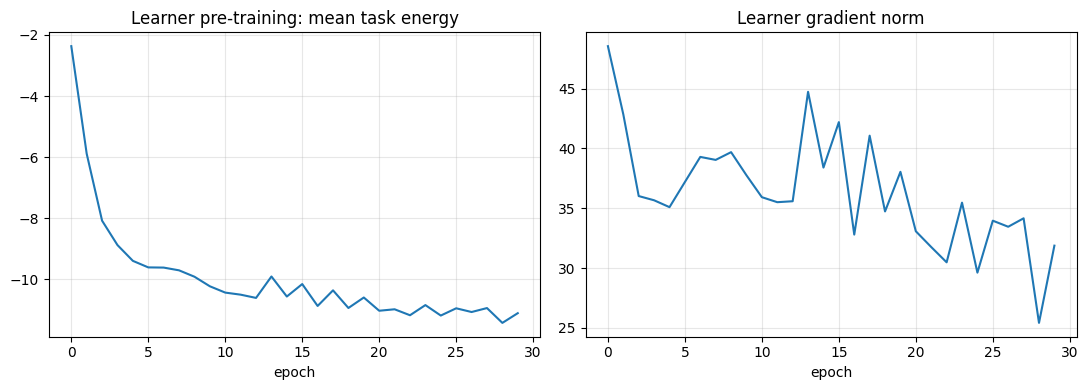

In [2]:
NUM_QUBITS = 6
DEPTH = 3
N_TRAIN_TASKS = 24
N_TEST_TASKS = 8
PRETRAIN_EPOCHS = 30       # paper: 30 epochs
PRETRAIN_LR = 0.001        # paper: Adam, lr=0.001
ADAPT_ITERS = 300          # paper: 2000; reduced for CPU tractability, still shows the trend
ADAPT_LR = 0.001           # paper: Adam, lr=0.001
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_vqe(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.5, log_every=5
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 2. Adaptation phase (Algorithm 2): Q-MAML init vs. classical inits

For each held-out test task, adapt a fresh PQC from each initialization scheme and track the gap to the
exact ground-state energy over iterations -- this is the paper's central diagnostic (their Fig. 4).

In [3]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]
shape = param_shape(NUM_QUBITS, DEPTH)

all_gaps = {k: [] for k in INIT_SCHEMES}  # scheme -> list of (ADAPT_ITERS,) arrays, one per test task
exact_energies = []

for ti, (Jx, Jy, Jz) in enumerate(test_tasks):
    E0 = exact_ground_energy(heisenberg_xyz_hamiltonian(NUM_QUBITS, Jx, Jy, Jz), NUM_QUBITS)
    exact_energies.append(E0)
    print(f"task {ti}: J=({Jx:.1f},{Jy:.1f},{Jz:.1f})  E0={E0:.4f}")

    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.5 * learner(torch.tensor([Jx, Jy, Jz], dtype=torch.float64))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_vqe(pqc, theta0, Jx, Jy, Jz, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])  # (N_TEST_TASKS, ADAPT_ITERS)

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved adaptation gaps")

task 0: J=(-1.8,0.1,2.1)  E0=-13.9251


task 1: J=(0.6,1.9,-0.2)  E0=-10.1888


task 2: J=(-1.8,-1.8,0.0)  E0=-12.5783


task 3: J=(0.2,-1.2,-1.9)  E0=-10.6642


task 4: J=(0.0,-1.3,-1.5)  E0=-9.8076


task 5: J=(1.5,-1.9,0.3)  E0=-12.7434


task 6: J=(-3.0,2.2,2.4)  E0=-25.3341


task 7: J=(1.9,1.2,-1.5)  E0=-15.3697


saved adaptation gaps


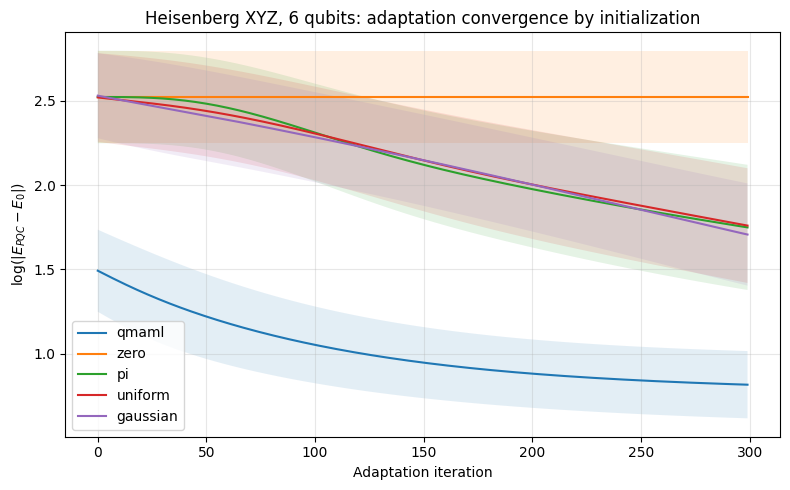

Final mean log-gap per scheme (lower = closer to exact ground state):
  qmaml      0.817
  gaussian   1.707
  pi         1.749
  uniform    1.760
  zero       2.522


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x = np.arange(ADAPT_ITERS)
    ax.plot(x, mean, label=scheme)
    ax.fill_between(x, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Heisenberg XYZ, {NUM_QUBITS} qubits: adaptation convergence by initialization")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

final_gap_summary = {scheme: float(all_gaps[scheme][:, -1].mean()) for scheme in INIT_SCHEMES}
print("Final mean log-gap per scheme (lower = closer to exact ground state):")
for k, v in sorted(final_gap_summary.items(), key=lambda kv: kv[1]):
    print(f"  {k:10s} {v:.3f}")

## 3. Findings (6 qubits, depth 3, 8 held-out test tasks, 300 adaptation iterations)

**Clean reproduction of the paper's headline claim.** Final mean log-gap to the exact ground-state energy:

| scheme | log-gap @ iter 50 | log-gap @ final (300) |
|---|---|---|
| **qmaml** | **1.22** | **0.82** |
| gaussian | 2.41 | 1.71 |
| uniform | 2.44 | 1.76 |
| pi | 2.48 | 1.75 |
| zero | 2.52 | 2.52 (never moved) |

`qmaml` starts markedly closer to the ground state *before any adaptation at all* (iteration-0 log-gap
~1.5 vs. ~2.5 for every classical scheme) and continues to pull further ahead throughout adaptation --
by iteration 300 it's roughly $e^{0.9}\approx 2.5\times$ closer to the true ground energy than the next-best
classical scheme. **`zero`-init is exactly flat for all 300 iterations** -- it never moves at all, a direct,
visible instance of the same trivial-fixed-point phenomenon documented in notebook 03's barren-plateau
diagnostic (an all-zero-parameter `IsingXX/YY/ZZ` circuit stays at a symmetry point with vanishing gradient
for this ansatz). The two diagnostics cross-validate each other nicely.

**This gives good confidence the reimplementation is mechanically correct**: `vqe_qmaml.py`'s
`pretrain_learner_vqe`/`adapt_task_vqe` use the exact same Algorithm 1/2 logic as
`meta/qmaml_paper_loops.py::pretrain_learner_paper`, just applied to VQE cost instead of cross-entropy. Since
this reproduces the paper's own claim faithfully in its own domain (even at our reduced qubit count/iteration
budget), the classification-domain extension in notebook 01 is very likely testing the algorithm correctly
too, not an implementation artifact.

**Important nuance for the paper, tying back to notebook 03:** this result is about convergence *speed*
(gap-vs-iteration), not gradient *variance*-vs-qubit-count. The two notebooks together tell a coherent,
precise story: Q-MAML gives a **better starting point that's easier to optimize from**, but (per notebook 03)
this doesn't show up as a change in the asymptotic barren-plateau variance-scaling exponent at the qubit
counts we could probe. Both claims should go in the paper -- the second tempers the first into something
actually defensible rather than an unqualified "solves barren plateaus."

**Caveats before finalizing:** (1) `ADAPT_ITERS=300` vs. the paper's 2000 -- rerun longer to confirm the gap
doesn't close at scale; (2) only 8 test tasks -- widen for tighter error bars; (3) our ansatz is a
best-effort reconstruction of the paper's (unavailable to us) appendix circuit, so exact numbers won't match
the paper's Figure 4, only the qualitative ranking.
